# Results

Reads a run directory produced by `ham10000-train` and reports what the model actually does. Every number here comes from files on disk, so the notebook cannot drift from the run it describes.

## Load the run

In [1]:
import json
from pathlib import Path

import pandas as pd

from ham10000.config import Settings
from ham10000.experiment import load_config

settings = Settings.resolve()

# Pinned rather than "most recent", so this notebook always describes the
# seven-class model discussed in 00 and 01..
run = next(
    p for p in sorted((settings.root / "models").iterdir())
    if p.name.startswith("balanced-with-random-crop") and not p.name.endswith("-smoke")
)

config = load_config(run / "config.yaml")
predictions = pd.read_csv(run / "predictions.csv")
losses = json.loads((run / "model.losses.json").read_text())

print(f"run        {run.name}")
print(f"experiment {config.name}")
print(f"epochs     {config.training.epochs}")

run        balanced-with-random-crop-0165f8afa21f
experiment Balanced with random crop
epochs     10


The directory name is a hash of the configuration, so it identifies exactly one experiment. `config.yaml` sits beside the artefacts and is the authoritative record of what produced them.

In [2]:
print((run / "config.yaml").read_text())

name: Balanced with random crop
description: 'Adds random cropping and switches to using every image of each training
  lesion. Validation lesions are repeated three times so that the stochastic transform
  yields three views per lesion, which are then aggregated.

  '
classes:
- mel
- nv
- bkl
- bcc
- akiec
- vasc
- df
split:
  train_val_ratio: 3
  seed: 0
  keep_first: false
  stratified: true
training:
  epochs: 10
  batch_size: 32
  learning_rate: 0.0001
  save_best: false
  seed: 0
architecture: resnet18
freeze_strategy: last_block
n_blocks: 1
pretrained: true
transform:
- name: RandomCrop
  size:
  - 300
  - 300
- name: Resize
  size:
  - 224
  - 224
- name: ToTensor
- name: Normalize
  mean:
  - 0.485
  - 0.456
  - 0.406
  std:
  - 0.229
  - 0.224
  - 0.225
balance:
  mel: 1000
  nv: 1000
  bkl: 1000
  bcc: 1000
  akiec: 1000
  vasc: 1000
  df: 1000
train_one_image_per_lesion: false
validation_expansion: 3



## Training curves

The first thing to look at, and the first thing that goes wrong.

lowest validation loss : epoch 5  (0.5676)
saved checkpoint       : epoch 10  (0.6649)


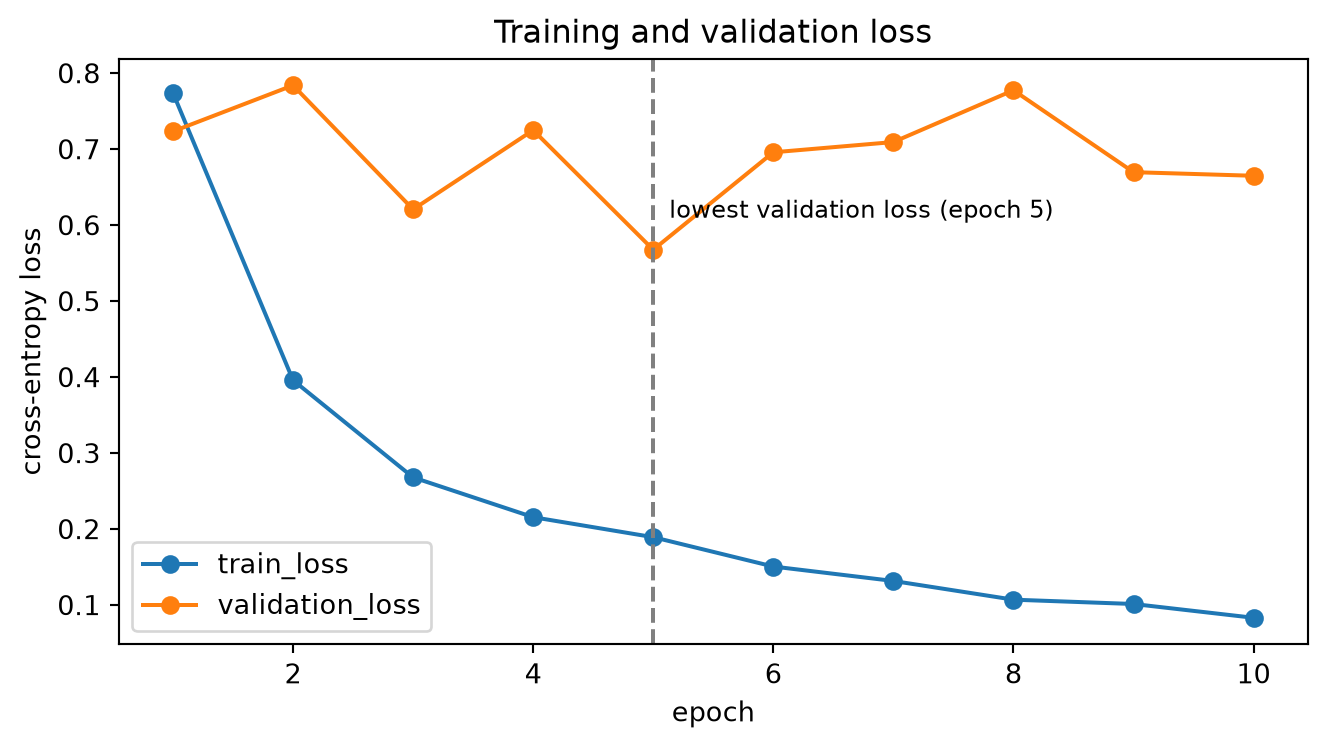

In [3]:
#| label: fig-losses
#| fig-cap: "Training and validation loss, with the lowest-validation epoch marked."
import matplotlib.pyplot as plt

history = pd.DataFrame(losses)
history.index = range(1, len(history) + 1)
history.index.name = "epoch"

best = int(history["validation_loss"].idxmin())
saved = len(history)

figure, axis = plt.subplots(figsize=(7, 4))
history.plot(ax=axis, marker="o")
axis.axvline(best, color="grey", linestyle="--")
axis.annotate(f"lowest validation loss (epoch {best})",
              xy=(best, history["validation_loss"].min()),
              xytext=(6, 12), textcoords="offset points", fontsize=9)
axis.set_ylabel("cross-entropy loss")
axis.set_title("Training and validation loss")
figure.tight_layout()

print(f"lowest validation loss : epoch {best}  ({history.loc[best, 'validation_loss']:.4f})")
print(f"saved checkpoint       : epoch {saved}  ({history.loc[saved, 'validation_loss']:.4f})")

If the two epochs above differ (@fig-losses), the saved model is not the best model this run produced. Training keeps the final epoch unless `save_best` is set, and this run's configuration is shown above.

The gap between training and validation loss measures overfitting directly. Widening after the validation minimum means the network is memorising the training set, and the training set here contains deliberate repetition, since balancing oversamples the rare classes.

Setting `save_best: true` keeps the lowest-validation-loss epoch instead, with two caveats. Choosing an epoch by validation loss and then reporting validation metrics is selection on the evaluation set, which makes the reported score optimistic by an unknown amount; a held-out test set exists for this data, but this project does not use it. And the selection criterion is not the reported metric, so the lowest-loss epoch is not necessarily the most accurate one: on the demo model, `save_best` gave 0.839 balanced accuracy where the final epoch gave 0.860.

## Overall performance

Metrics are computed **per lesion**, not per image. A lesion photographed five times counts once, otherwise the score would silently weight the much-photographed lesions, which are disproportionately the ambiguous and malignant ones.

In [4]:
from ham10000.data.labels import LabelScheme
from ham10000.evaluation.metrics import evaluate

scheme = LabelScheme.build(config.classes, set(predictions["dx"].unique()))
per_lesion = predictions.drop_duplicates(subset="lesion_id")

report = evaluate(per_lesion["label"].to_numpy(), per_lesion["pred_final"].to_numpy())

chance = 1 / scheme.n_classes
skill = (report.balanced_accuracy - chance) / (1 - chance)

print(f"lesions evaluated   {report.n_samples:,}")
print(f"classes             {scheme.n_classes}")
print(f"balanced accuracy   {report.balanced_accuracy:.4f}")
print(f"chance level        {chance:.4f}")
print(f"skill above chance  {skill:.4f}")
print(f"plain accuracy      {report.accuracy:.4f}  (misleading on its own)")

lesions evaluated   1,870
classes             7
balanced accuracy   0.6813
chance level        0.1429
skill above chance  0.6282
plain accuracy      0.8203  (misleading on its own)


**Balanced accuracy is the headline, and chance level is why.** Plain accuracy rewards predicting the majority class: answering "nevus" every time scores 0.72 on this dataset while being clinically useless. This model scores 0.82, so it is doing better than that, but the figure alone cannot tell you whether it is doing better by recognising lesions or by having learned the same prior more subtly. Balanced accuracy, the mean of per-class recall, scores the always-nevus strategy at `1/n_classes` and so cannot be gamed that way.

Skill above chance, `(score - chance) / (1 - chance)`, is what makes results comparable across tasks with different class counts. Chance is 0.143 for seven classes and 0.500 for two, so a binary model scoring 0.78 has less skill (0.56) than this seven-class model scoring 0.68 (0.63).

## Per-class performance

The overall number hides what matters. Recall per class is the clinically meaningful view, and melanoma's row is the one to read first.

In [5]:
#| label: tbl-confusion
#| tbl-cap: "Confusion matrix with per-class recall and support."
from ham10000.reporting import confusion_with_recall

table = confusion_with_recall(
    per_lesion["label"].to_numpy(), per_lesion["pred_final"].to_numpy(), scheme.codes
)
table

pred,akiec,bcc,bkl,df,mel,nv,vasc,support,recall
true,,,,,,,,,
akiec,36,9,6,0,5,1,0,57,0.6316
bcc,6,65,7,0,3,0,1,82,0.7927
bkl,11,4,132,1,17,16,1,182,0.7253
df,2,3,4,8,0,2,0,19,0.4211
mel,4,2,24,1,93,30,0,154,0.6039
nv,9,9,47,2,99,1182,3,1351,0.8749
vasc,0,1,2,0,1,3,18,25,0.7200


`support` is the number of validation lesions of that class. Read recall against it: a recall of 1.00 over 18 lesions is not evidence of anything much, while the same figure over 1,300 would be.

In [6]:
if "mel" in table.index:
    sensitivity = table.loc["mel", "recall"]
    missed = int(table.loc["mel", "support"] - table.loc["mel", "mel"])
    print(f"melanoma sensitivity : {sensitivity:.3f}")
    print(f"melanomas missed     : {missed} of {int(table.loc['mel', 'support'])}")
    print()
    print("Where the missed melanomas went:")
    # Drop the `mel` column too: those are the melanomas correctly identified,
    # not misses.
    row = table.loc["mel"].drop(["support", "recall", "mel"])
    print(row[row > 0].sort_values(ascending=False).to_string())

melanoma sensitivity : 0.604
melanomas missed     : 61 of 154

Where the missed melanomas went:
pred
nv       30.0
bkl      24.0
akiec     4.0
bcc       2.0
df        1.0


**This is the number that matters** (@tbl-confusion)**.** For a screening tool, a melanoma called a nevus is a missed cancer; a nevus called a melanoma is a biopsy. The errors are not symmetric and the metric should not pretend they are. Not all misses are equal either. Of the 61 melanomas missed, 30 were called ordinary moles. The other 31 were called basal cell carcinoma, keratosis, or actinic keratosis, all of which would still send a patient to a dermatologist. Only those 30 are failures in the sense that matters: a melanoma called `bcc` gets looked at, a melanoma called `nv` gets sent home.

## Limitations

**The held-out test set is not used.** Every figure above comes from the validation split, which is also the split used to choose thresholds and aggregation rules. These are model-selection scores, not held-out estimates, and they are optimistic by an unknown amount. A test set exists for this data, the ISIC 2018 Task 3 set, and evaluating against it would give a cleaner number. It has not been done here: the model overfits visibly from epoch 5 and does not perform well on validation, so a held-out figure would confirm a conclusion the validation figures already support.

**One run, one seed.** The reported balanced accuracy of 0.68 is 0.69 with a 95% confidence interval of 0.685 to 0.703, measured over ten evaluations of this checkpoint. That interval covers only the variation from random cropping at evaluation time. It says nothing about the variation between training runs with different seeds, which is likely larger and has not been measured. Two configurations differing by a few points of balanced accuracy are not necessarily different.

**The rare classes rest on very few lesions.** Dermatofibroma has 54 lesions in the training split, repeated roughly twelve times per epoch to meet the balancing target. Its recall says more about those 54 lesions than about the class.

**A single image may not contain the answer.** About one melanoma in ten is featureless, showing no diagnostic dermatoscopic criteria at all, and in a controlled study of lesions under surveillance, 59.2% of those eventually excised had no dermatoscopic features of malignancy at the time of removal: they came out because sequential images compared side by side showed the lesion had changed. Both figures are reported by @hassani2023tbp, whose own two cases are melanomas found by an operator noticing a size change that the detection software had not flagged. Every figure above is an accuracy figure for one photograph of one lesion. That is not always the information a diagnosis rests on, and for around one melanoma in ten it cannot be.

**The dataset's populations are undocumented.** HAM10000 reports no ethnicity or Fitzpatrick skin type. Classifiers trained on one population routinely underperform on another [@wen2022datasets]. Nothing here addresses that.

**This is not a diagnostic tool.** It is a teaching artefact. The correct response to a concerning lesion is to see a dermatologist.